<a href="https://colab.research.google.com/github/Abi-ijlan/Panda_study/blob/main/history_segments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()  # upload your historical_production.csv when prompted

df = pd.read_csv(list(uploaded.keys())[0])

Saving historical_production.csv to historical_production.csv


In [3]:
df.head()

,Project,Dec-21,Jan-22,Feb-22,Mar-22,Apr-22,May-22,Jun-22,Jul-22,Aug-22,...,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Total
0,HSR-C6 SBS,1.0,1.0,0.0,1.0,16.0,25.0,30.0,35.0,59.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5251
1,MABP Viaduct SBS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,112,112.0,150.0,129.0,137.0,82.0,118.0,86.0,65.0,3344
2,MABP MB SBS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,89,124.0,148.0,141.0,148.0,125.0,98.0,93.0,83.0,2283
3,MPSB Palasbari SBS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22,25.0,25.0,26.0,25.0,25.0,25.0,25.0,9.0,243
4,MPSB Sualkuchi SBS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17,21.0,19.0,22.0,25.0,25.0,25.0,25.0,20.0,209


In [10]:
month_cols = [c for c in df.columns if c not in ['Project', 'Total']]

In [16]:
df[month_cols] = df[month_cols].apply(pd.to_numeric, errors='coerce')
df['Avg_Monthly']  = df[month_cols].mean(axis=1).round(1)
df['Peak_Monthly'] = df[month_cols].max(axis=1)
df['Peak_Month']   = df[month_cols].idxmax(axis=1)

result = df[['Project', 'Avg_Monthly', 'Peak_Monthly', 'Peak_Month']].copy()

In [17]:
result.head()

,Project,Avg_Monthly,Peak_Monthly,Peak_Month
0,HSR-C6 SBS,114.5,244.0,Jan-24
1,MABP Viaduct SBS,72.8,150.0,Dec-25
2,MABP MB SBS,56.5,148.0,Dec-25
3,MPSB Palasbari SBS,21.4,26.0,Jan-26
4,MPSB Sualkuchi SBS,19.5,25.0,Feb-26


In [18]:
projects    = result['Project'].tolist()
avg_vals    = result['Avg_Monthly'].tolist()
peak_vals   = result['Peak_Monthly'].tolist()
peak_months = result['Peak_Month'].tolist()

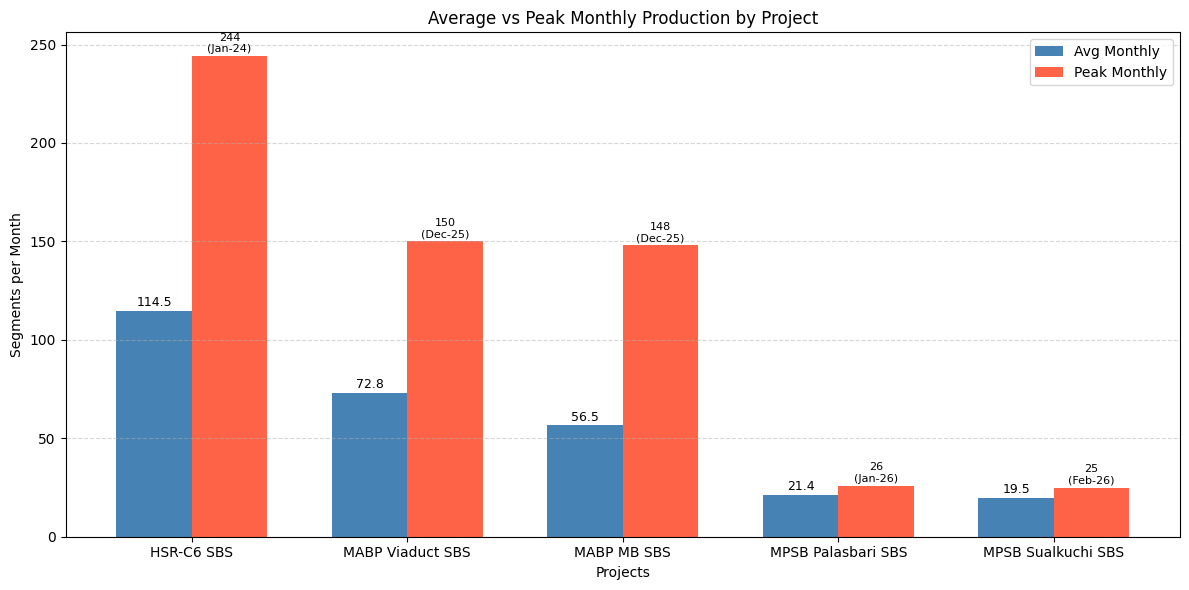

In [34]:
x     = np.arange(len(projects))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_avg  = ax.bar(x - width/2, avg_vals,  width, label='Avg Monthly',  color='steelblue')
bars_peak = ax.bar(x + width/2, peak_vals, width, label='Peak Monthly', color='tomato')

# Value labels on avg bars
for bar in bars_avg:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

# Value labels on peak bars
for bar, month in zip(bars_peak, peak_months):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}\n({month})', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Projects')
ax.set_ylabel('Segments per Month')
ax.set_title('Average vs Peak Monthly Production by Project')
ax.set_xticks(x)                                          # ← fix 1: set tick positions first
ax.set_xticklabels(projects, rotation=0, ha='center')     # ← fix 1: then assign labels
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('avg_vs_peak_production.png', dpi=150)        # ← fix 2: save BEFORE show()
plt.show()

### Individual Monthly Production Charts (Smoothed)

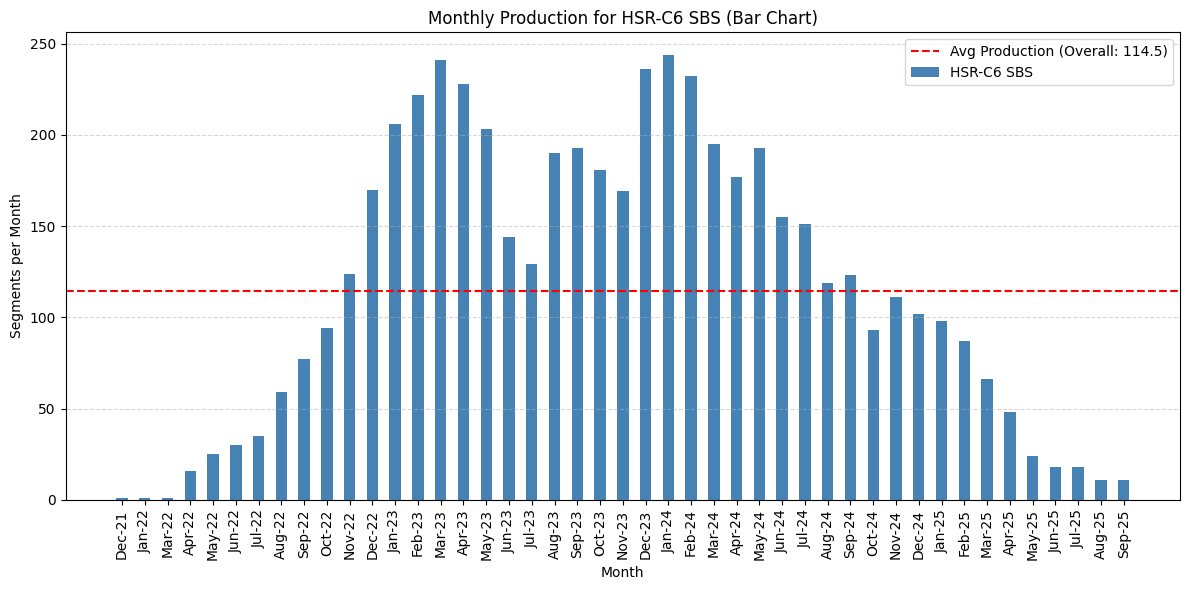

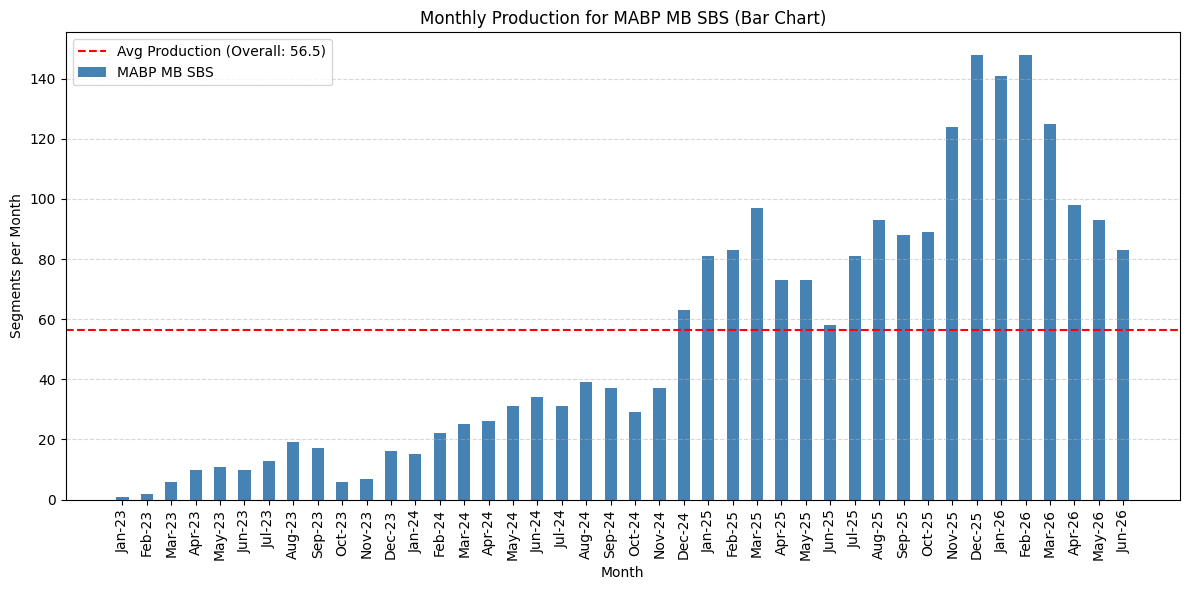

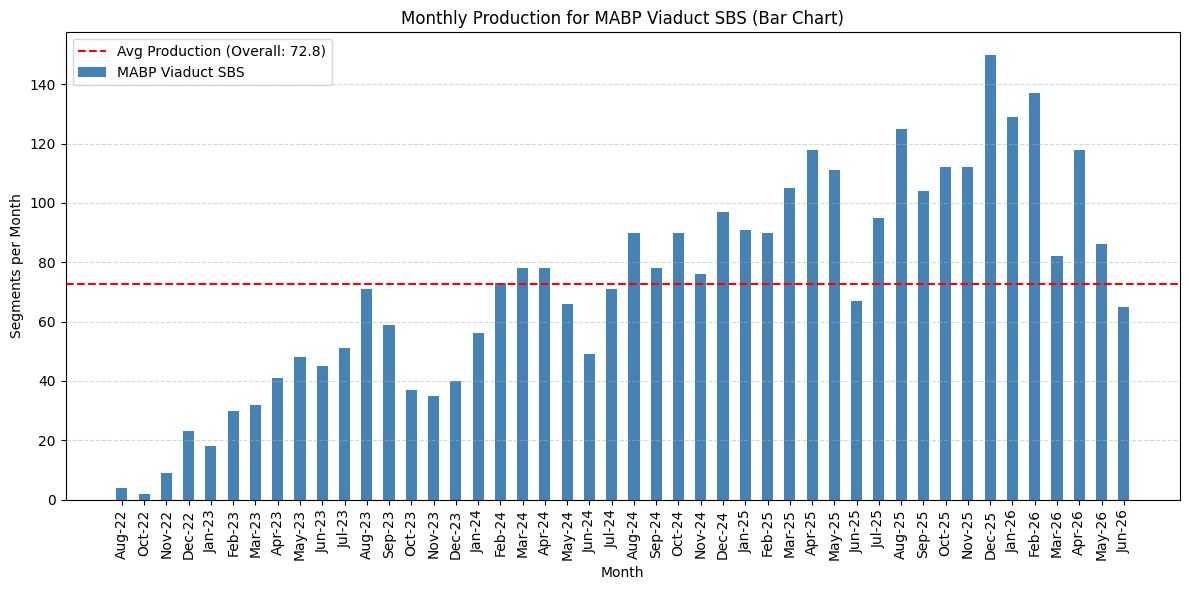

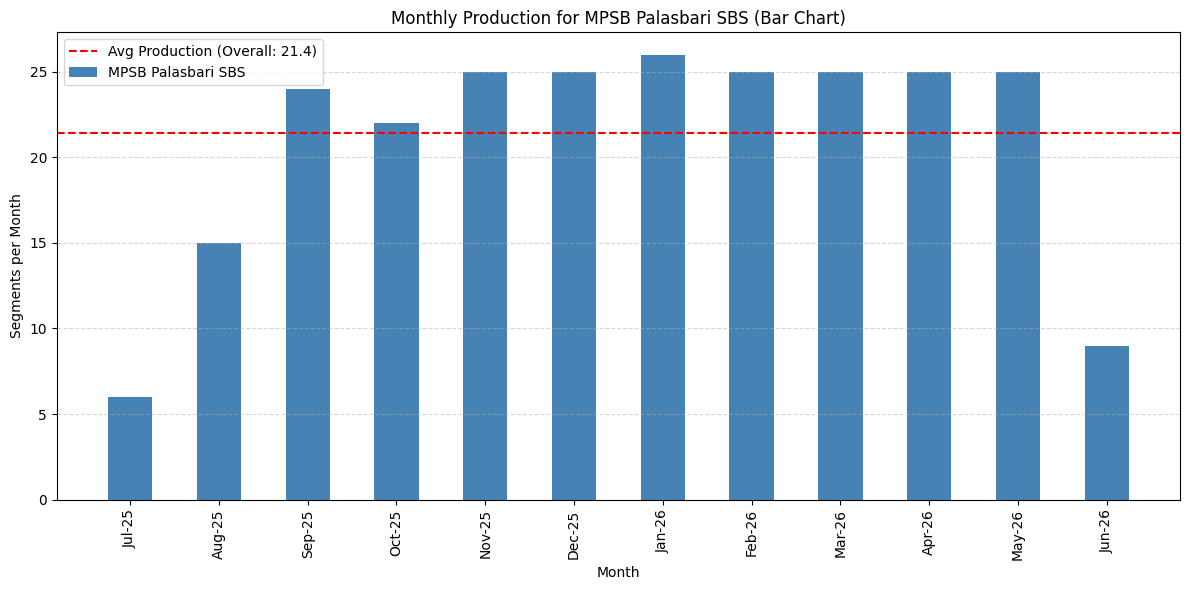

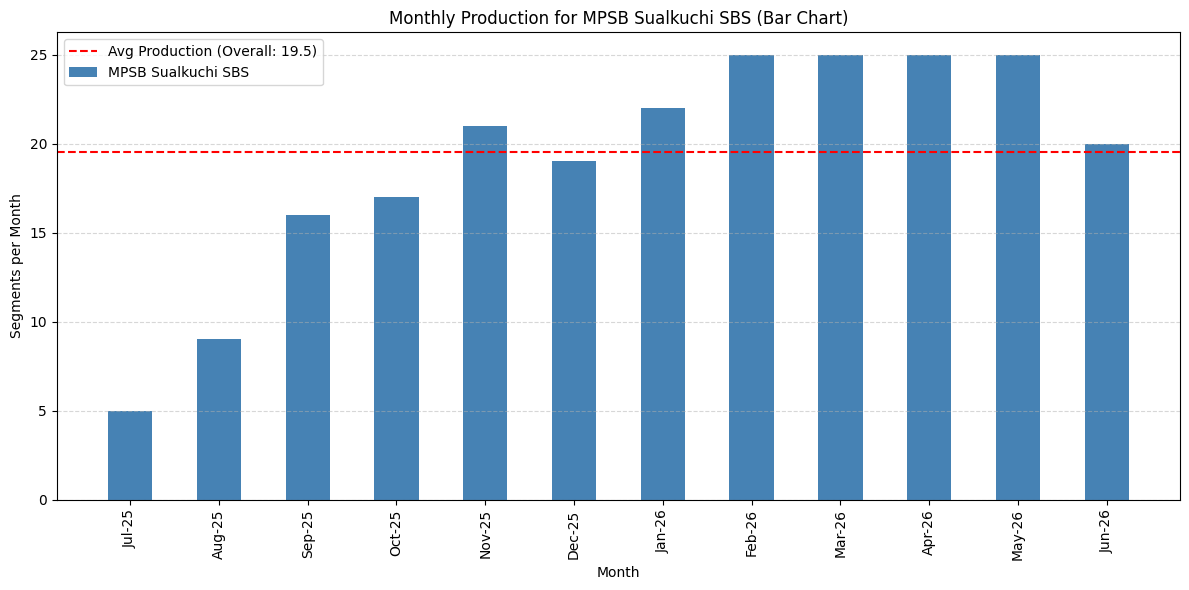

In [50]:
for project in df_long['Project'].unique():
    proj_data = df_long[df_long['Project'] == project]

    # Filter out months where Production is not greater than zero
    proj_data = proj_data[proj_data['Production'] > 0]

    # Skip plotting if no production data exists after filtering
    if proj_data.empty:
        print(f"No production data ( > 0 ) for {project}. Skipping chart generation.")
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.5 # Reduced width for better visual separation

    # Use numerical positions for bars and set month labels explicitly
    x_positions = np.arange(len(proj_data)) # Generate numerical positions for each bar
    ax.bar(x_positions, proj_data['Production'], width=bar_width, label=project, color='steelblue')

    # Calculate and plot average production line using the pre-calculated avg_vals
    project_index = projects.index(project)
    average_production_overall = avg_vals[project_index]
    ax.axhline(average_production_overall, color='red', linestyle='--', label=f'Avg Production (Overall: {average_production_overall:.1f})')

    ax.set_xlabel('Month')
    ax.set_ylabel('Segments per Month')
    ax.set_title(f'Monthly Production for {project} (Bar Chart)') # Updated title for bar chart
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Set x-ticks to be at the numerical positions and labels to be the month strings
    ax.set_xticks(x_positions)
    ax.set_xticklabels(proj_data['Month'], rotation=90, ha='center') # Use the string 'Month' column for labels
    plt.tight_layout()
    # Sanitize project name for filename
    filename_project = project.replace(' ', '_').replace('/', '-').replace('SBS', '')
    plt.savefig(f'{filename_project}_monthly_production_barchart.png', dpi=150) # Updated filename for bar chart
    plt.show()